11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.2529 - val_loss: 0.1689
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1523 - val_loss: 0.1391
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1336 - val_loss: 0.1261
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1238 - val_loss: 0.1191
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1178 - val_loss: 0.1140
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1133 - val_loss: 0.1097
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.1099 - val_loss: 0.1073
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1072 - val_loss: 0.1047
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1050 - val_loss: 0.1026
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1033 - val_loss: 0.1013
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


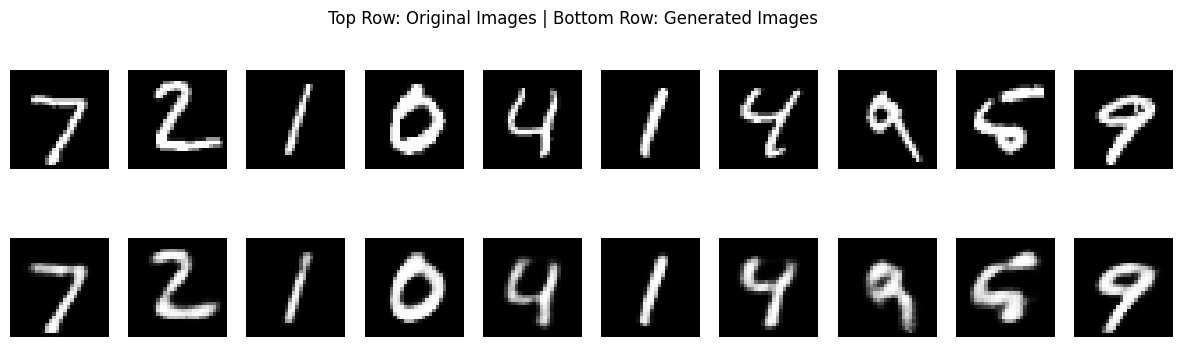

In [1]:
# Experiment 4: Generative Multi-Layer Network Model using MNIST

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images: 28x28 = 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Input layer
input_img = Input(shape=(784,))

# Encoder - multilayer network
encoded = Dense(128, activation="relu")(input_img)
encoded = Dense(64, activation="relu")(encoded)
encoded = Dense(32, activation="relu")(encoded)

# Decoder - generative part
decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dense(784, activation="sigmoid")(decoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Compile model
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

# Train model
autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Generate/reconstruct images
reconstructed_images = autoencoder.predict(x_test[:10])

# Display original and generated images
plt.figure(figsize=(15, 4))

for i in range(10):
    # Original image
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Generated image
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Top Row: Original Images | Bottom Row: Generated Images")
plt.show()
